<a href="https://colab.research.google.com/github/Wasim2006-dev/phoneinfoga/blob/master/banglore_house_price_prediction_Rrgression_project_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files

In [3]:
uploaded=files.upload()

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data.csv


In [5]:
df=pd.read_csv('Bengaluru_House_Data.csv')
print(df)

                  area_type   availability                  location  \
0      Super built-up  Area         19-Dec  Electronic City Phase II   
1                Plot  Area  Ready To Move          Chikka Tirupathi   
2            Built-up  Area  Ready To Move               Uttarahalli   
3      Super built-up  Area  Ready To Move        Lingadheeranahalli   
4      Super built-up  Area  Ready To Move                  Kothanur   
...                     ...            ...                       ...   
13315        Built-up  Area  Ready To Move                Whitefield   
13316  Super built-up  Area  Ready To Move             Richards Town   
13317        Built-up  Area  Ready To Move     Raja Rajeshwari Nagar   
13318  Super built-up  Area         18-Jun           Padmanabhanagar   
13319  Super built-up  Area  Ready To Move              Doddathoguru   

            size  society total_sqft  bath  balcony   price  
0          2 BHK  Coomee        1056   2.0      1.0   39.07  
1      4 Be

In [7]:
df.shape

(13320, 9)

In [9]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [10]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


#remove nan value from society

In [14]:
df=df.dropna(subset=['society'])

In [16]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00


drop rows where avaibality looks like a data

In [17]:
df = df[~df["availability"].str.match(r"^\d{1,2}-[A-Za-z]{3}$", na=False)]

In [18]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.0
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.0
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.0


#remove plot area from area_type

In [23]:
df = df[df["area_type"] != "Plot Area"]
print(df["area_type"].value_counts())
df.to_csv("Bengaluru_House_Data_no_plot_area.csv", index=False)
df.head()

area_type
Super built-up  Area    4564
Built-up  Area          1109
Plot  Area               259
Carpet  Area              33
Name: count, dtype: int64


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.0
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.0
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.0


#covert float to integer

In [25]:
df["bath"] = df["bath"].fillna(0).astype(int)
df["balcony"] = df["balcony"].fillna(0).astype(int)
df["price"] = df["price"].astype(int)

# Check data types
print(df[["bath", "balcony", "price"]].dtypes)

# Save cleaned dataset
df.to_csv("Bengaluru_House_Data_cleaned.csv", index=False)

bath       int64
balcony    int64
price      int64
dtype: object


In [26]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5,3,120
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3,1,95
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2,1,38
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4,0,600
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5,3,295


In [27]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 2: Load dataset
df = pd.read_csv("Bengaluru_House_Data_cleaned.csv")

# Step 3: Drop unnecessary columns (if present)
if "society" in df.columns:
    df = df.drop("society", axis=1)

# Step 4: Remove missing values
df = df.dropna()

# Step 5: Encode categorical columns
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Step 6: Features and target
X = df.drop("price", axis=1)
y = df["price"]

# Step 7: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 8: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 9: Prediction
y_pred = model.predict(X_test)

# Step 10: Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE : 43.359890496787884
RMSE: 66.68882215518522
R2 Score: 0.47669179829316644


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.7298943875682533


# co-relation heatmap

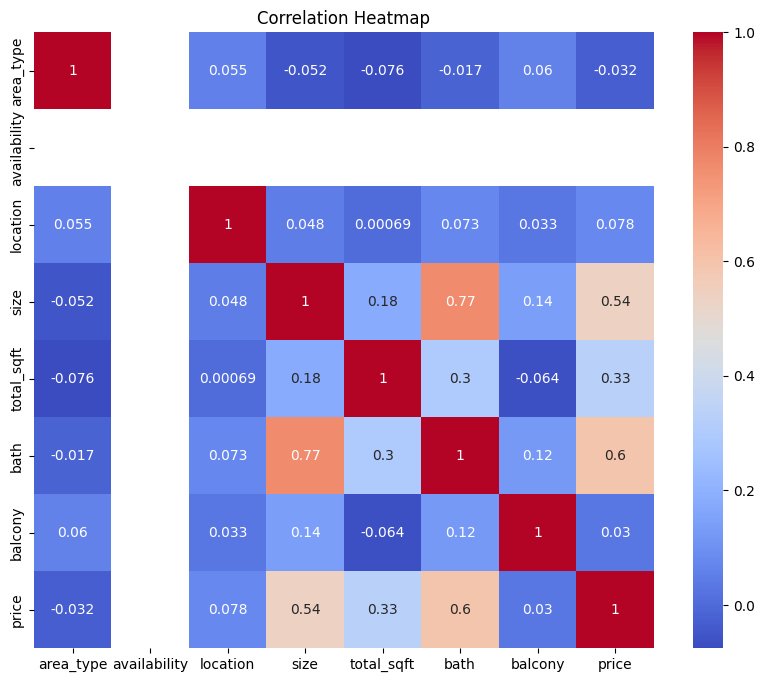

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#price distribution

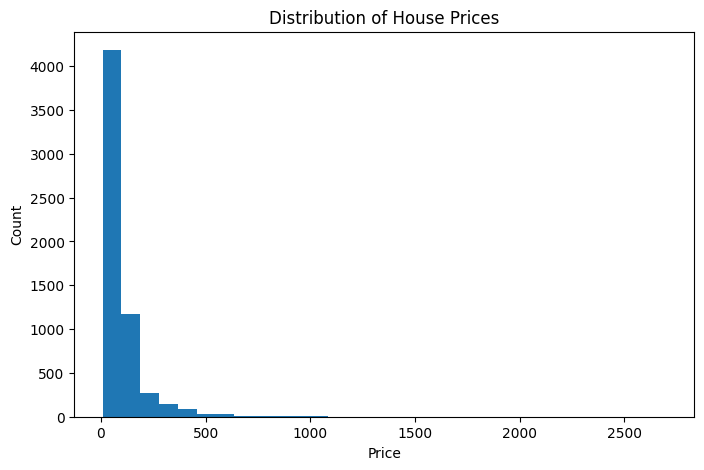

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

#price vs total sqft

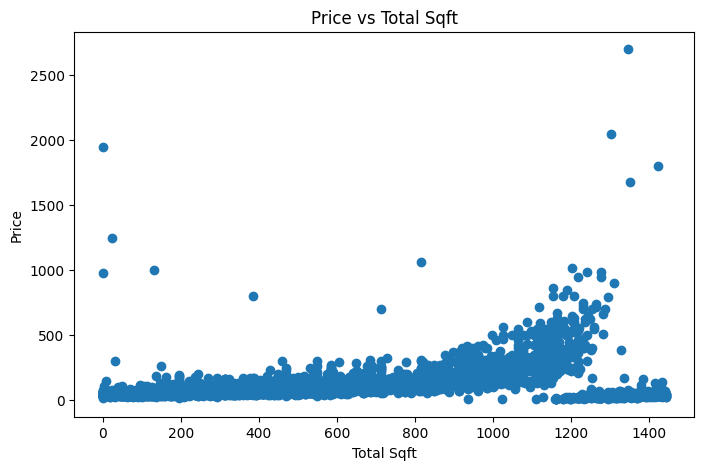

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(df["total_sqft"], df["price"])
plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.title("Price vs Total Sqft")
plt.show()

#actual price vs predicted price

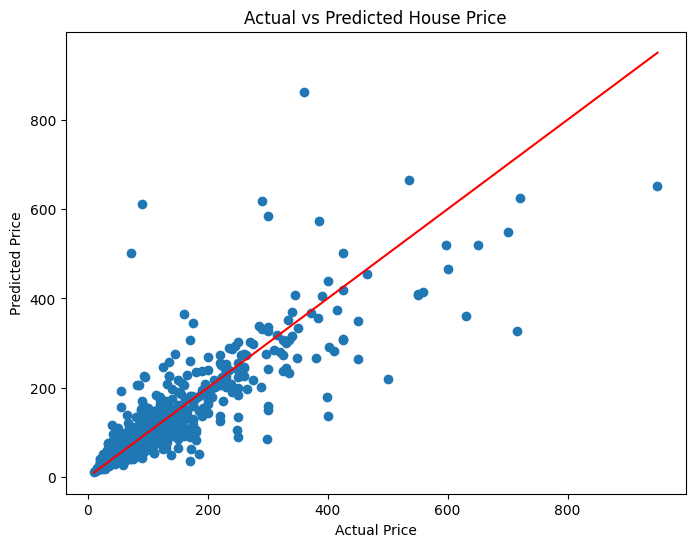

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

residual plot

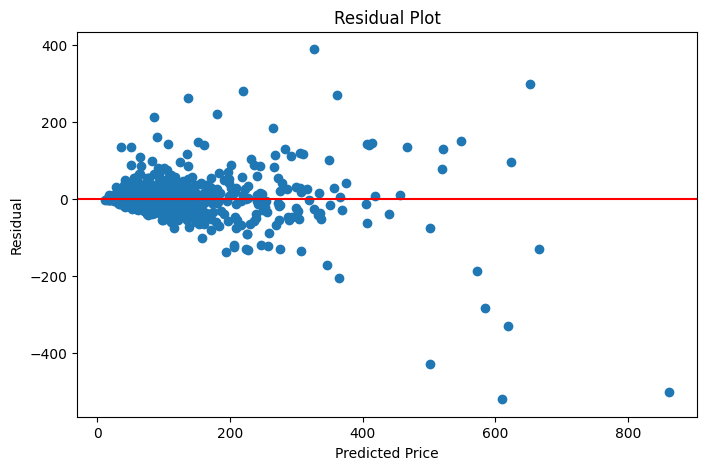

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

#feature importance

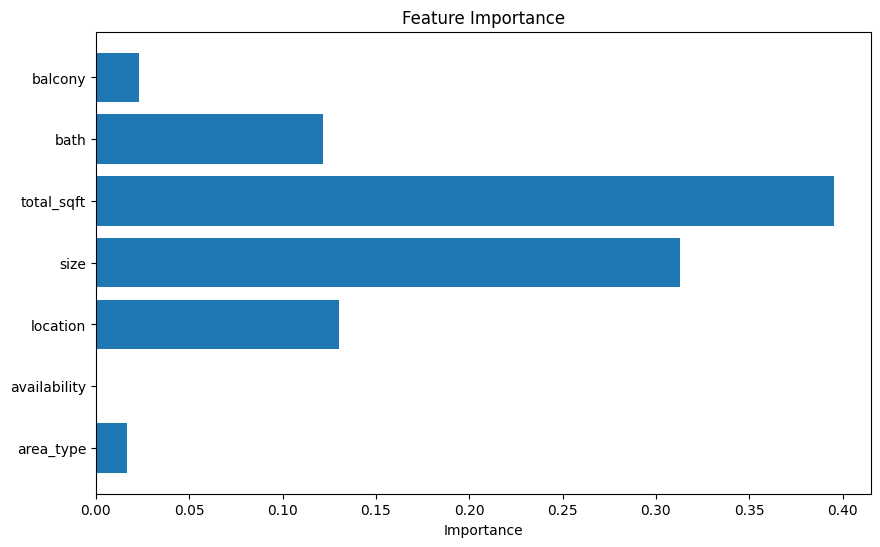

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importance = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()